In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

# ---------------- مسارات الداتا ----------------
images_path = "BCCD/JPEGImages"
annotations_path = "BCCD/Annotations"

all_images = sorted([f for f in os.listdir(images_path) if f.endswith(".jpg")])
test_images = all_images[:30] # هنجرب على 30 صورة كعينة

def get_actual_counts(img_name):
    """قراءة العدد الحقيقي للـ RBCs والـ WBCs من ملف الـ XML"""
    xml_name = img_name.replace(".jpg", ".xml")
    xml_file = os.path.join(annotations_path, xml_name)

    counts = {"RBC": 0, "WBC": 0}

    if not os.path.exists(xml_file):
        return counts

    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        label = obj.find("name").text
        if label in counts:
            counts[label] += 1

    return counts

In [3]:
def get_wbc_mask(img):
    """
    عزل النواة البنفسجية للـ WBCs باستخدام HSV Color Space
    [Project Description 2.1]
    """
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # حطينا قيم أضيق شوية عشان نقلل النغمشة بناءً على تجربتك
    lower_purple = np.array([115, 50, 80])
    upper_purple = np.array([160, 255, 255])

    binary_mask = cv2.inRange(hsv, lower_purple, upper_purple)
    return binary_mask

In [4]:
def clean_wbc_noise(binary_mask):
    """
    تنظيف الماسك باستخدام الـ Morphological Operations والـ Median Filter
    [Matrix Image Filtering Section]
    """
    # 1. سد الفراغات جوه النواة لو موجودة (Closing)
    kernel = np.ones((5,5), np.uint8)
    mask_closed = cv2.morphologyEx(binary_mask, cv2.MORPH_CLOSE, kernel)

    # 2. مسح كل النقط الصغيرة اللي ظهرت معاك في الصورة (Median Filter)
    cleaned_mask = cv2.medianBlur(mask_closed, 7)

    return cleaned_mask

In [5]:
def extract_wbc_contours(cleaned_mask, min_wbc_area=1000):
    """
    التأكد إن دي WBC حقيقية عن طريق الحجم
    """
    contours, _ = cv2.findContours(
        cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    wbc_contours = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        # أي حاجة مساحتها أكبر من 1000 هنعتبرها WBC
        if area > min_wbc_area:
            wbc_contours.append(cnt)

    return wbc_contours

def draw_wbcs(img_rgb, wbc_contours):
    """رسم الـ WBCs باللون الأحمر"""
    img_out = img_rgb.copy()
    for cnt in wbc_contours:
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(img_out, (x, y), (x + w, y + h), (255, 0, 0), 3)
        cv2.putText(img_out, "WBC", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)
    return img_out

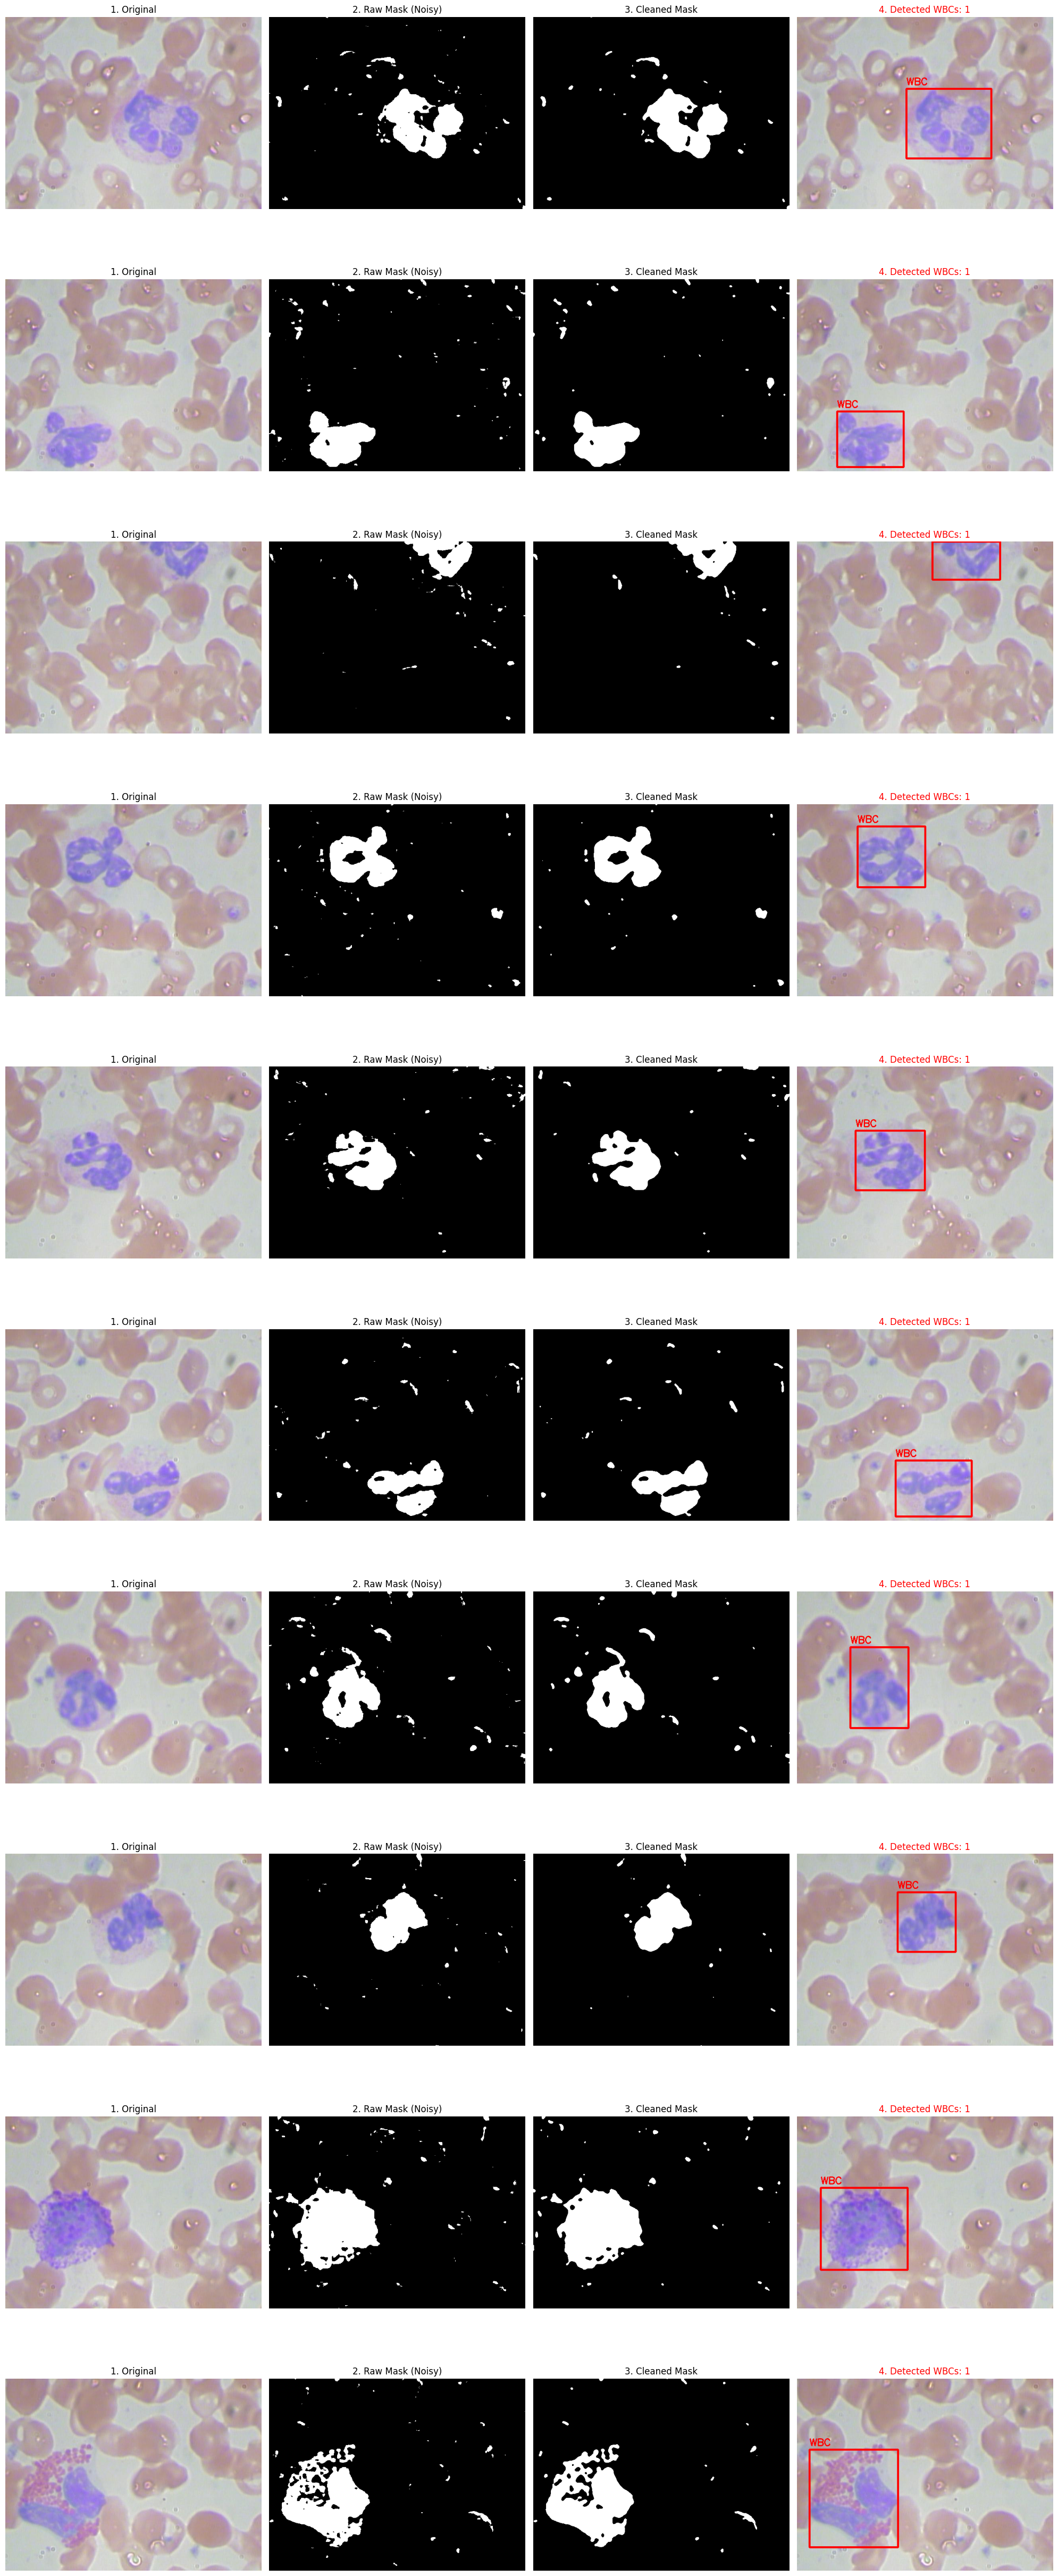

In [7]:

num_samples = 10
plt.figure(figsize=(20, 5 * num_samples))

for i, img_name in enumerate(test_images[:num_samples]):
    img_path = os.path.join(images_path, img_name)
    img = cv2.imread(img_path)
    if img is None: continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # تشغيل الكود
    raw_mask = get_wbc_mask(img)
    clean_mask = clean_wbc_noise(raw_mask)
    wbc_cnts = extract_wbc_contours(clean_mask)
    result_img = draw_wbcs(img_rgb, wbc_cnts)

    # عرض
    base_idx = i * 4
    plt.subplot(num_samples, 4, base_idx + 1); plt.imshow(img_rgb); plt.title("1. Original"); plt.axis("off")
    plt.subplot(num_samples, 4, base_idx + 2); plt.imshow(raw_mask, cmap="gray"); plt.title("2. Raw Mask (Noisy)"); plt.axis("off")
    plt.subplot(num_samples, 4, base_idx + 3); plt.imshow(clean_mask, cmap="gray"); plt.title("3. Cleaned Mask"); plt.axis("off")
    plt.subplot(num_samples, 4, base_idx + 4); plt.imshow(result_img); plt.title(f"4. Detected WBCs: {len(wbc_cnts)}", color="red"); plt.axis("off")

plt.tight_layout()
plt.show()